Import bibliotek

In [2]:
# IMPORT BIBLIOTEK

import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import  RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier


Import danych

In [3]:
# IMPORT DANYCH

df = pd.read_csv("data/new_data.csv")


Rozgrupowanie na zm. objaśniające i objaśniane

In [4]:
X = df.drop(columns=["Class", "ID"])
y = df["Class"]
groups = df["ID"]

In [5]:
y_num = (df["Class"] == "ADHD").astype(int)

Prawidłowy split

In [6]:
cv = GroupKFold(n_splits=5)

Do dalszej analizy wybrano kilka klasycznych modeli uczenia maszynowego, które dobrze sprawdzają się w problemach klasyfikacyjnych przy stosunkowo niewielkich zbiorach danych. W szczególności wybrane zostały modele, które w wielu zastosowaniach tabelarycznych osiągają lepsze wyniki niż proste sieci neuronowe.
 * Logistic Regression – model liniowy stanowiący punkt odniesienia (baseline) dla bardziej złożonych metod.
 * Support Vector Machine (SVM) – model wyznaczający hiperpłaszczyznę maksymalizującą margines między klasami, który dzięki zastosowaniu funkcji jądra (np. RBF) pozwala modelować również nieliniowe zależności w danych.
 * Random Forest – zespół wielu drzew decyzyjnych uczonych na losowych podzbiorach danych i cech, zdolny do modelowania bardziej złożonych zależności między zmiennymi, choć mniej interpretowalny niż modele liniowe.
 * XGBoost – metoda boostingowa oparta na drzewach decyzyjnych, w której kolejne modele uczą się na błędach poprzednich, co często prowadzi do bardzo dobrych wyników na danych tabelarycznych.
 * MLP - prosta sieć neuronowa

In [7]:
models = {

    "LogReg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        # model ma 100 iteracji
        ("model", LogisticRegression(max_iter=100, random_state=123))

    ]),

    "SVM_RBF": Pipeline([

        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        # JĄDRO RBF pozwala na modelowanie zakrzywionych hiperpłaszczyzn a nie prostych
        # Na podstawie PCA z EDA można wnioskować, że to lepszy wybór
        ("model", SVC(kernel="rbf", random_state=123))

    ]),

    "RandomForest": Pipeline([

        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            # Model oparty na 367 drzewach 
            n_estimators=367,
            random_state=123
        ))

    ]),

    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(
            # 367 drzew w modelu
            n_estimators=367,
            # maksymalna głębokość pojedynczego drzewa na 4
            max_depth=4,
            # lr
            learning_rate=0.05,
            # każde drzewo uczy się na 80% obserwacji, to działa jak regularyzacja
            subsample=0.8,
            # każde drzewo widzi tylko 80% cech, kolejny sposób na regularyzację
            colsample_bytree=0.8,
            # kara za zbyt duże/ agresywne dopasowanie
            reg_lambda=1.0,
            # mierzy jakość przewidywanych prawdopodobieństw
            eval_metric="logloss",

        ))
    ]),

    "MLP": Pipeline([

        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=2000,
            early_stopping=True,
            random_state=42
        ))
        
    ]),
}

## Benchmark bazowy

In [8]:
results = []
scoring = ["accuracy", "balanced_accuracy", "f1", "roc_auc"]

for name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X,
        y_num,
        cv=cv,
        groups=groups,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results.append({
        "model": name,
        "acc_mean": scores["test_accuracy"].mean(),
        "bal_acc_mean": scores["test_balanced_accuracy"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
    })

results_df = pd.DataFrame(results).sort_values("roc_auc_mean", ascending=False)
print(results_df.round(3))

          model  acc_mean  bal_acc_mean  f1_mean  roc_auc_mean
3       XGBoost     0.776         0.777    0.782         0.859
2  RandomForest     0.768         0.770    0.776         0.842
0        LogReg     0.775         0.774    0.779         0.839
1       SVM_RBF     0.760         0.761    0.773         0.827
4           MLP     0.487         0.486    0.581         0.525


Wstępny benchmark pokazuje wszystkie wyniki najlepsze dla XGBoost

Hyperparameter tuning dla tego klasyfikatora

In [9]:


pipe_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

# fine tuning

param_grid = {
    "model__n_estimators": [100, 200, 300, 500, 600],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 2, 4, 6],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search = RandomizedSearchCV(
    estimator=pipe_xgb,
    param_distributions=param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    random_state=42
)

search.fit(X, y_num, groups=groups)

print(search.best_score_)

0.8748737373737374


Najlepsze parametry: {'model__subsample': 0.8, 'model__reg_lambda': 2.0, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.15, 'model__colsample_bytree': 0.5}
Best CV ROC-AUC: 0.8749
Accuracy: 0.7851
Balanced accuracy: 0.7851
F1: 0.7869
ROC-AUC: 0.8667

Classification report:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78        60
           1       0.79      0.79      0.79        61

    accuracy                           0.79       121
   macro avg       0.79      0.79      0.79       121
weighted avg       0.79      0.79      0.79       121



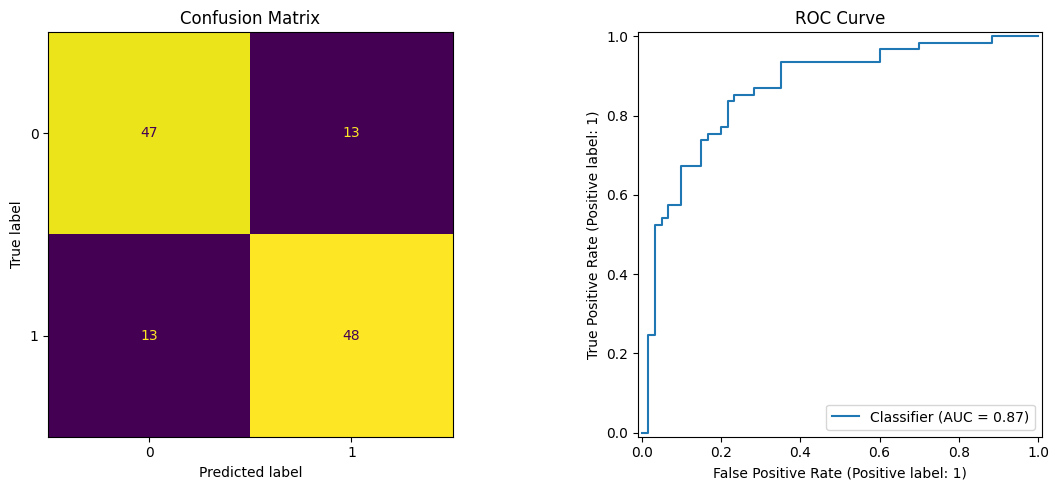

In [10]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt

best_model = search.best_estimator_
print("Najlepsze parametry:", search.best_params_)
print("Best CV ROC-AUC:", round(search.best_score_, 4))

# Predykcje out-of-fold
y_pred = cross_val_predict(
    best_model,
    X,
    y_num,
    cv=cv,
    groups=groups,
    method="predict",
    n_jobs=-1
)

# Prawdopodobieństwa out-of-fold
y_proba = cross_val_predict(
    best_model,
    X,
    y_num,
    cv=cv,
    groups=groups,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Metryki
print("Accuracy:", round(accuracy_score(y_num, y_pred), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_num, y_pred), 4))
print("F1:", round(f1_score(y_num, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_num, y_proba), 4))

print("\nClassification report:")
print(classification_report(y_num, y_pred))

# Confusion matrix
cm = confusion_matrix(y_num, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_num, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

Najlepsze accuracy dla XGBoost, 87% uważam to za bardzo zadowalający wynik z uwagi na mały zbiór uczący jak i testowe (łącznie 121 obs)

W eksperymencie porównano pięć klasyfikatorów: regresję logistyczną, maszynę wektorów nośnych z jądrem RBF, Random Forest, XGBoost oraz wielowarstwowy perceptron (MLP). Regresja logistyczna stanowi model liniowy, SVM umożliwia nieliniową separację klas, Random Forest i XGBoost reprezentują podejście oparte na zespołach drzew decyzyjnych, natomiast MLP jest prostą siecią neuronową zdolną do modelowania bardziej złożonych zależności. Dla modeli wrażliwych na skalę cech zastosowano standaryzację, a we wszystkich przypadkach braki danych uzupełniono medianą.